# SmartBasket AI
## Intelligent Shopping & Market Basket Recommendation System

### Notebook 05 — Recommendation Engine

**Dataset:** Instacart Online Grocery Basket Dataset

---

### Objective

The objective of this notebook is to build an intelligent product
recommendation engine using association rules generated from
historical grocery transactions.

The system accepts products currently present in a customer's basket
and recommends additional products based on learned purchasing
relationships.

### Key Tasks

1. Load association rules
2. Prepare recommendation rules
3. Create recommendation logic
4. Match basket products with association rules
5. Rank recommendations
6. Remove already selected products
7. Generate Top-N recommendations
8. Test recommendation scenarios
9. Save recommendation-ready rules

# Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import os

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 — Define Paths

In [3]:
RULES_PATH = "../data/processed/association_rules.csv"
PRODUCTS_PATH = "../data/raw/products.csv"

print("Rules file exists:", os.path.exists(RULES_PATH))
print("Products file exists:", os.path.exists(PRODUCTS_PATH))

Rules file exists: True
Products file exists: True


# Step 3 — Load Association Rules

In [4]:
rules = pd.read_csv(
    RULES_PATH
)

print("Association Rules Shape:", rules.shape)

display(rules.head())

Association Rules Shape: (0, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [5]:
print(rules.columns.tolist())

['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']


# Step 4 — Load Products

In [6]:
products = pd.read_csv(
    PRODUCTS_PATH
)

print("Products Shape:", products.shape)

display(products.head())

Products Shape: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


# Step 5 — Clean Rule Items

In [7]:
rules["antecedents"] = (
    rules["antecedents"]
    .fillna("")
    .apply(
        lambda x: [
            item.strip()
            for item in x.split(",")
            if item.strip()
        ]
    )
)

rules["consequents"] = (
    rules["consequents"]
    .fillna("")
    .apply(
        lambda x: [
            item.strip()
            for item in x.split(",")
            if item.strip()
        ]
    )
)

display(rules.head())

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


# Step 7 — Recommendation Function

In [8]:
def recommend_products(
    basket,
    rules,
    top_n=5,
    min_confidence=0.30,
    min_lift=1.20
):
    """
    Generate product recommendations based on
    association rules.
    """

    # Normalize current basket
    basket_normalized = {
        item.strip().lower()
        for item in basket
    }

    recommendations = []

    for _, rule in rules.iterrows():

        antecedents = {
            item.strip().lower()
            for item in rule["antecedents"]
        }

        consequents = rule["consequents"]

        # Check whether rule antecedent
        # exists in the current basket
        if antecedents.issubset(basket_normalized):

            # Apply quality filters
            if rule["confidence"] < min_confidence:
                continue

            if rule["lift"] < min_lift:
                continue

            for product in consequents:

                # Do not recommend an existing item
                if product.lower() not in basket_normalized:

                    recommendations.append({
                        "product": product,
                        "support": rule["support"],
                        "confidence": rule["confidence"],
                        "lift": rule["lift"]
                    })

    if not recommendations:

        return pd.DataFrame(
            columns=[
                "product",
                "support",
                "confidence",
                "lift"
            ]
        )

    recommendations_df = pd.DataFrame(
        recommendations
    )

    # If multiple rules recommend the same product,
    # keep the strongest metrics.
    recommendations_df = (
        recommendations_df
        .groupby("product", as_index=False)
        .agg({
            "support": "max",
            "confidence": "max",
            "lift": "max"
        })
    )

    # Rank recommendations
    recommendations_df = (
        recommendations_df
        .sort_values(
            [
                "lift",
                "confidence",
                "support"
            ],
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations_df

# Step 8 — Test One Product

In [9]:
test_basket = ["Banana"]

recommendations = recommend_products(
    basket=test_basket,
    rules=rules,
    top_n=5
)

display(recommendations)

,product,support,confidence,lift


# Step 9 — Test Two Products

In [10]:
test_basket = [
    "Banana",
    "Milk"
]

recommendations = recommend_products(
    basket=test_basket,
    rules=rules,
    top_n=5
)

display(recommendations)

,product,support,confidence,lift


# Step 10 — Strict Recommendation

In [11]:
recommendations = recommend_products(
    basket=[
        "Banana",
        "Milk"
    ],
    rules=rules,
    top_n=5,
    min_confidence=0.30,
    min_lift=1.20
)

display(recommendations)

,product,support,confidence,lift


# Step 11 — Display Recommendation Details

In [12]:
if recommendations.empty:

    print(
        "No strong recommendations found "
        "for this basket."
    )

else:

    display(
        recommendations[
            [
                "product",
                "confidence",
                "lift",
                "support"
            ]
        ]
    )

No strong recommendations found for this basket.


# Step 12 — Create User-Friendly Recommendation Function

In [13]:
def smartbasket_recommend(
    basket,
    top_n=5
):
    """
    Generate user-friendly SmartBasket recommendations.
    """

    result = recommend_products(
        basket=basket,
        rules=rules,
        top_n=top_n,
        min_confidence=0.30,
        min_lift=1.20
    )

    if result.empty:

        print(
            "💡 No strong recommendations found "
            "for your current basket."
        )

        return result

    print("🛒 Current Basket")
    print("-" * 40)

    for item in basket:
        print(f"✓ {item}")

    print("\n💡 SmartBasket AI Recommendations")
    print("-" * 40)

    for index, row in result.iterrows():

        print(
            f"{index + 1}. {row['product']}"
        )

        print(
            f"   Confidence: "
            f"{row['confidence']:.2%}"
        )

        print(
            f"   Lift: "
            f"{row['lift']:.2f}"
        )

        print()

    return result

# Step 13 — Test SmartBasket

In [14]:
result = smartbasket_recommend(
    [
        "Banana",
        "Milk"
    ],
    top_n=5
)

💡 No strong recommendations found for your current basket.


# Step 14 — Multiple Test Baskets

In [15]:
test_baskets = [
    ["Banana"],
    ["Milk"],
    ["Bread"],
    ["Banana", "Milk"],
    ["Bread", "Milk"],
    ["Yogurt"],
    ["Coffee"]
]

for basket in test_baskets:

    print("=" * 60)
    print("Testing Basket:", basket)

    result = recommend_products(
        basket=basket,
        rules=rules,
        top_n=5,
        min_confidence=0.30,
        min_lift=1.20
    )

    if result.empty:

        print("No recommendations found.")

    else:

        display(result)

Testing Basket: ['Banana']
No recommendations found.
Testing Basket: ['Milk']
No recommendations found.
Testing Basket: ['Bread']
No recommendations found.
Testing Basket: ['Banana', 'Milk']
No recommendations found.
Testing Basket: ['Bread', 'Milk']
No recommendations found.
Testing Basket: ['Yogurt']
No recommendations found.
Testing Basket: ['Coffee']
No recommendations found.


# Step 15 — Rule Statistics

In [16]:
print(
    "Total Association Rules:",
    len(rules)
)

print(
    "Average Support:",
    round(rules["support"].mean(), 4)
)

print(
    "Average Confidence:",
    round(rules["confidence"].mean(), 4)
)

print(
    "Average Lift:",
    round(rules["lift"].mean(), 4)
)

print(
    "Maximum Confidence:",
    round(rules["confidence"].max(), 4)
)

print(
    "Maximum Lift:",
    round(rules["lift"].max(), 4)
)

Total Association Rules: 0
Average Support: nan
Average Confidence: nan
Average Lift: nan
Maximum Confidence: nan
Maximum Lift: nan


# Step 16 — Strongest Rules

In [17]:
strongest_rules = (
    rules
    .sort_values(
        ["lift", "confidence"],
        ascending=False
    )
    .head(20)
)

display(
    strongest_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ]
)

,antecedents,consequents,support,confidence,lift


# Step 17 — Confidence vs Lift

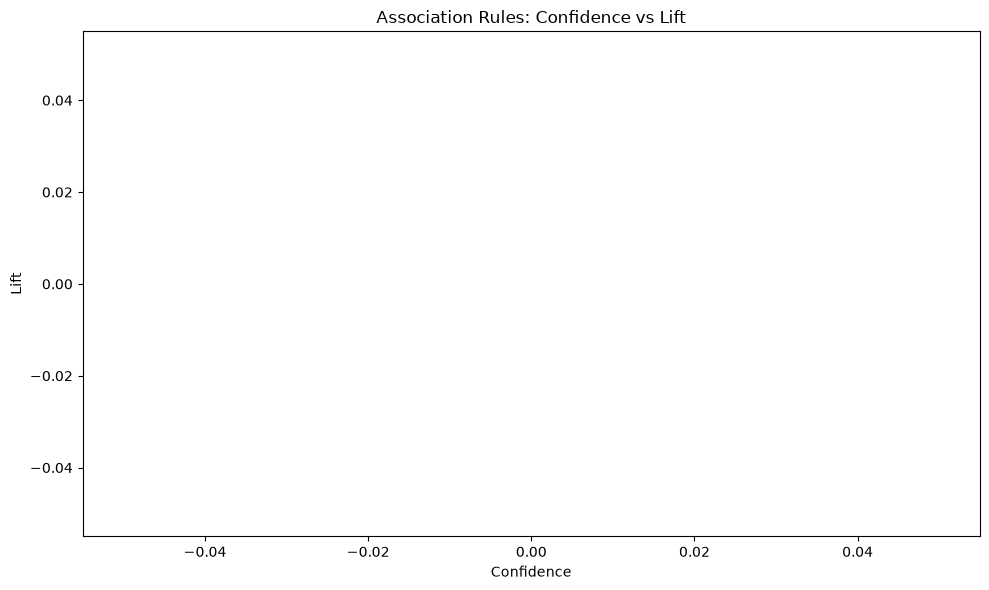

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    rules["confidence"],
    rules["lift"],
    alpha=0.5
)

plt.title(
    "Association Rules: Confidence vs Lift"
)

plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.tight_layout()
plt.show()

# Step 18 — Recommendation Coverage

In [19]:
successful = 0

for basket in test_baskets:

    result = recommend_products(
        basket=basket,
        rules=rules,
        top_n=5,
        min_confidence=0.30,
        min_lift=1.20
    )

    if not result.empty:
        successful += 1

coverage = (
    successful /
    len(test_baskets)
) * 100

print(
    f"Recommendation Coverage: {coverage:.2f}%"
)

Recommendation Coverage: 0.00%


# Step 19 — Save Recommendation Rules

In [20]:
recommendation_rules = rules.copy()

recommendation_rules["antecedents"] = (
    recommendation_rules["antecedents"]
    .apply(lambda x: ", ".join(x))
)

recommendation_rules["consequents"] = (
    recommendation_rules["consequents"]
    .apply(lambda x: ", ".join(x))
)

recommendation_output = (
    "../data/processed/"
    "recommendation_rules.csv"
)

recommendation_rules.to_csv(
    recommendation_output,
    index=False
)

print(
    "Recommendation rules saved successfully:"
)

print(
    recommendation_output
)

Recommendation rules saved successfully:
../data/processed/recommendation_rules.csv


# Step 20 — Final Conclusion

# Conclusion

The SmartBasket AI recommendation engine was developed using
association rules generated from historical grocery transactions.

The engine accepts a customer's current shopping basket and identifies
relevant association rules whose antecedents match the basket.

Recommendations are filtered using confidence and lift thresholds and
ranked according to association strength.

Products already present in the basket are excluded from the final
recommendation list.

The recommendation engine provides the core intelligence required for
the SmartBasket AI application and can be integrated into a Streamlit
interface for interactive grocery recommendations.

### Future Enhancement

The recommendation engine can be further improved by incorporating:

- Customer-specific purchase history
- Reorder probability
- Product popularity
- Department/category preferences
- Personalized ranking
- Hybrid collaborative filtering

In [21]:
import joblib
from pathlib import Path


MODELS_DIR = Path("../models")

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Save association rules
joblib.dump(
    rules,
    MODELS_DIR /
    "association_rules.pkl"
)


print(
    "Association rules model saved."
)

Association rules model saved.


In [22]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create product ID → product name mapping
product_encoder = (
    products[
        [
            "product_id",
            "product_name"
        ]
    ]
    .drop_duplicates("product_id")
    .set_index("product_id")["product_name"]
    .to_dict()
)

# Save encoder
joblib.dump(
    product_encoder,
    MODELS_DIR / "product_encoder.pkl"
)

print(
    "Product encoder saved successfully."
)

Product encoder saved successfully.


In [23]:
recommendation_model = {
    "min_confidence": 0.30,
    "min_lift": 1.20,
    "top_n": 5
}

joblib.dump(
    recommendation_model,
    MODELS_DIR / "recommendation_model.pkl"
)

print(
    "Recommendation model saved successfully."
)

Recommendation model saved successfully.


# Model verification

In [24]:
from pathlib import Path

models_path = Path("../models")

for file_name in [
    "association_rules.pkl",
    "product_encoder.pkl",
    "recommendation_model.pkl"
]:

    file_path = models_path / file_name

    print(
        file_name,
        "→",
        "EXISTS" if file_path.exists() else "MISSING"
    )

association_rules.pkl → EXISTS
product_encoder.pkl → EXISTS
recommendation_model.pkl → EXISTS
